In [1]:
# KAISON

In [2]:
file_path = "tabular_dataset/diabetes_012_health_indicators_BRFSS2015.csv"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

In [4]:
df_raw = pd.read_csv(file_path)

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
def col_box_plot (given_serise):
    value_counts = given_serise.value_counts()

    plt.figure(figsize=(4, 3))
    plt.bar(value_counts.index, value_counts.values)
    plt.xlabel('Value')
    plt.ylabel('Number of Cases')
    plt.title('Bar Chart of Column')
    plt.xticks(rotation=45)  # Rotate x labels if too crowded
    plt.show()

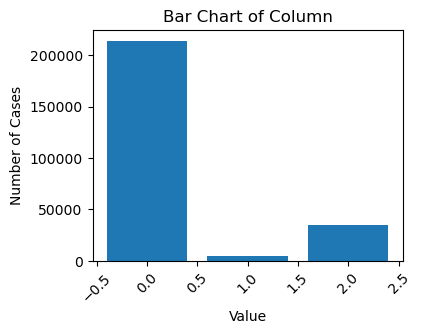

In [7]:
col_box_plot(df_raw['Diabetes_012'])

In [8]:
df_class_bi = df_raw.copy()

In [9]:
df_class_bi.loc[df_class_bi["Diabetes_012"] == 2, "Diabetes_012"] = 1

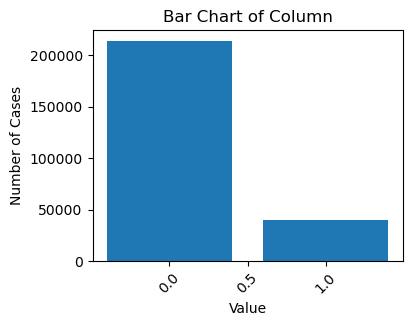

In [10]:
col_box_plot(df_class_bi['Diabetes_012'])

In [11]:
def dot_plt_all_features (given_df):
    cols = given_df.columns
    n_cols = 4  # number of plots in one row
    n_rows = (len(cols) + n_cols - 1) // n_cols  # calculate number of rows needed

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

    # If axes is 1D (only 1 row), make it 2D for easier looping
    axes = axes.reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        ax.plot(given_df.index, given_df[col], 'o')
        ax.set_title(col)
        ax.set_xlabel('Index')
        ax.set_ylabel(col)

    # Hide any empty subplots (if number of columns isn't divisible by 4)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [12]:
# df_no_dup = df_raw.copy()
df_no_dup = df_class_bi.copy()

In [13]:
duplicates = df_no_dup.duplicated()
print(duplicates.sum())

23968


In [14]:
df_no_dup = df_no_dup.drop_duplicates().reset_index(drop=True)

In [15]:
duplicates_new = df_no_dup.duplicated()
print(duplicates_new.sum())

0


In [16]:
df_no_dup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229712 entries, 0 to 229711
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          229712 non-null  float64
 1   HighBP                229712 non-null  float64
 2   HighChol              229712 non-null  float64
 3   CholCheck             229712 non-null  float64
 4   BMI                   229712 non-null  float64
 5   Smoker                229712 non-null  float64
 6   Stroke                229712 non-null  float64
 7   HeartDiseaseorAttack  229712 non-null  float64
 8   PhysActivity          229712 non-null  float64
 9   Fruits                229712 non-null  float64
 10  Veggies               229712 non-null  float64
 11  HvyAlcoholConsump     229712 non-null  float64
 12  AnyHealthcare         229712 non-null  float64
 13  NoDocbcCost           229712 non-null  float64
 14  GenHlth               229712 non-null  float64
 15  

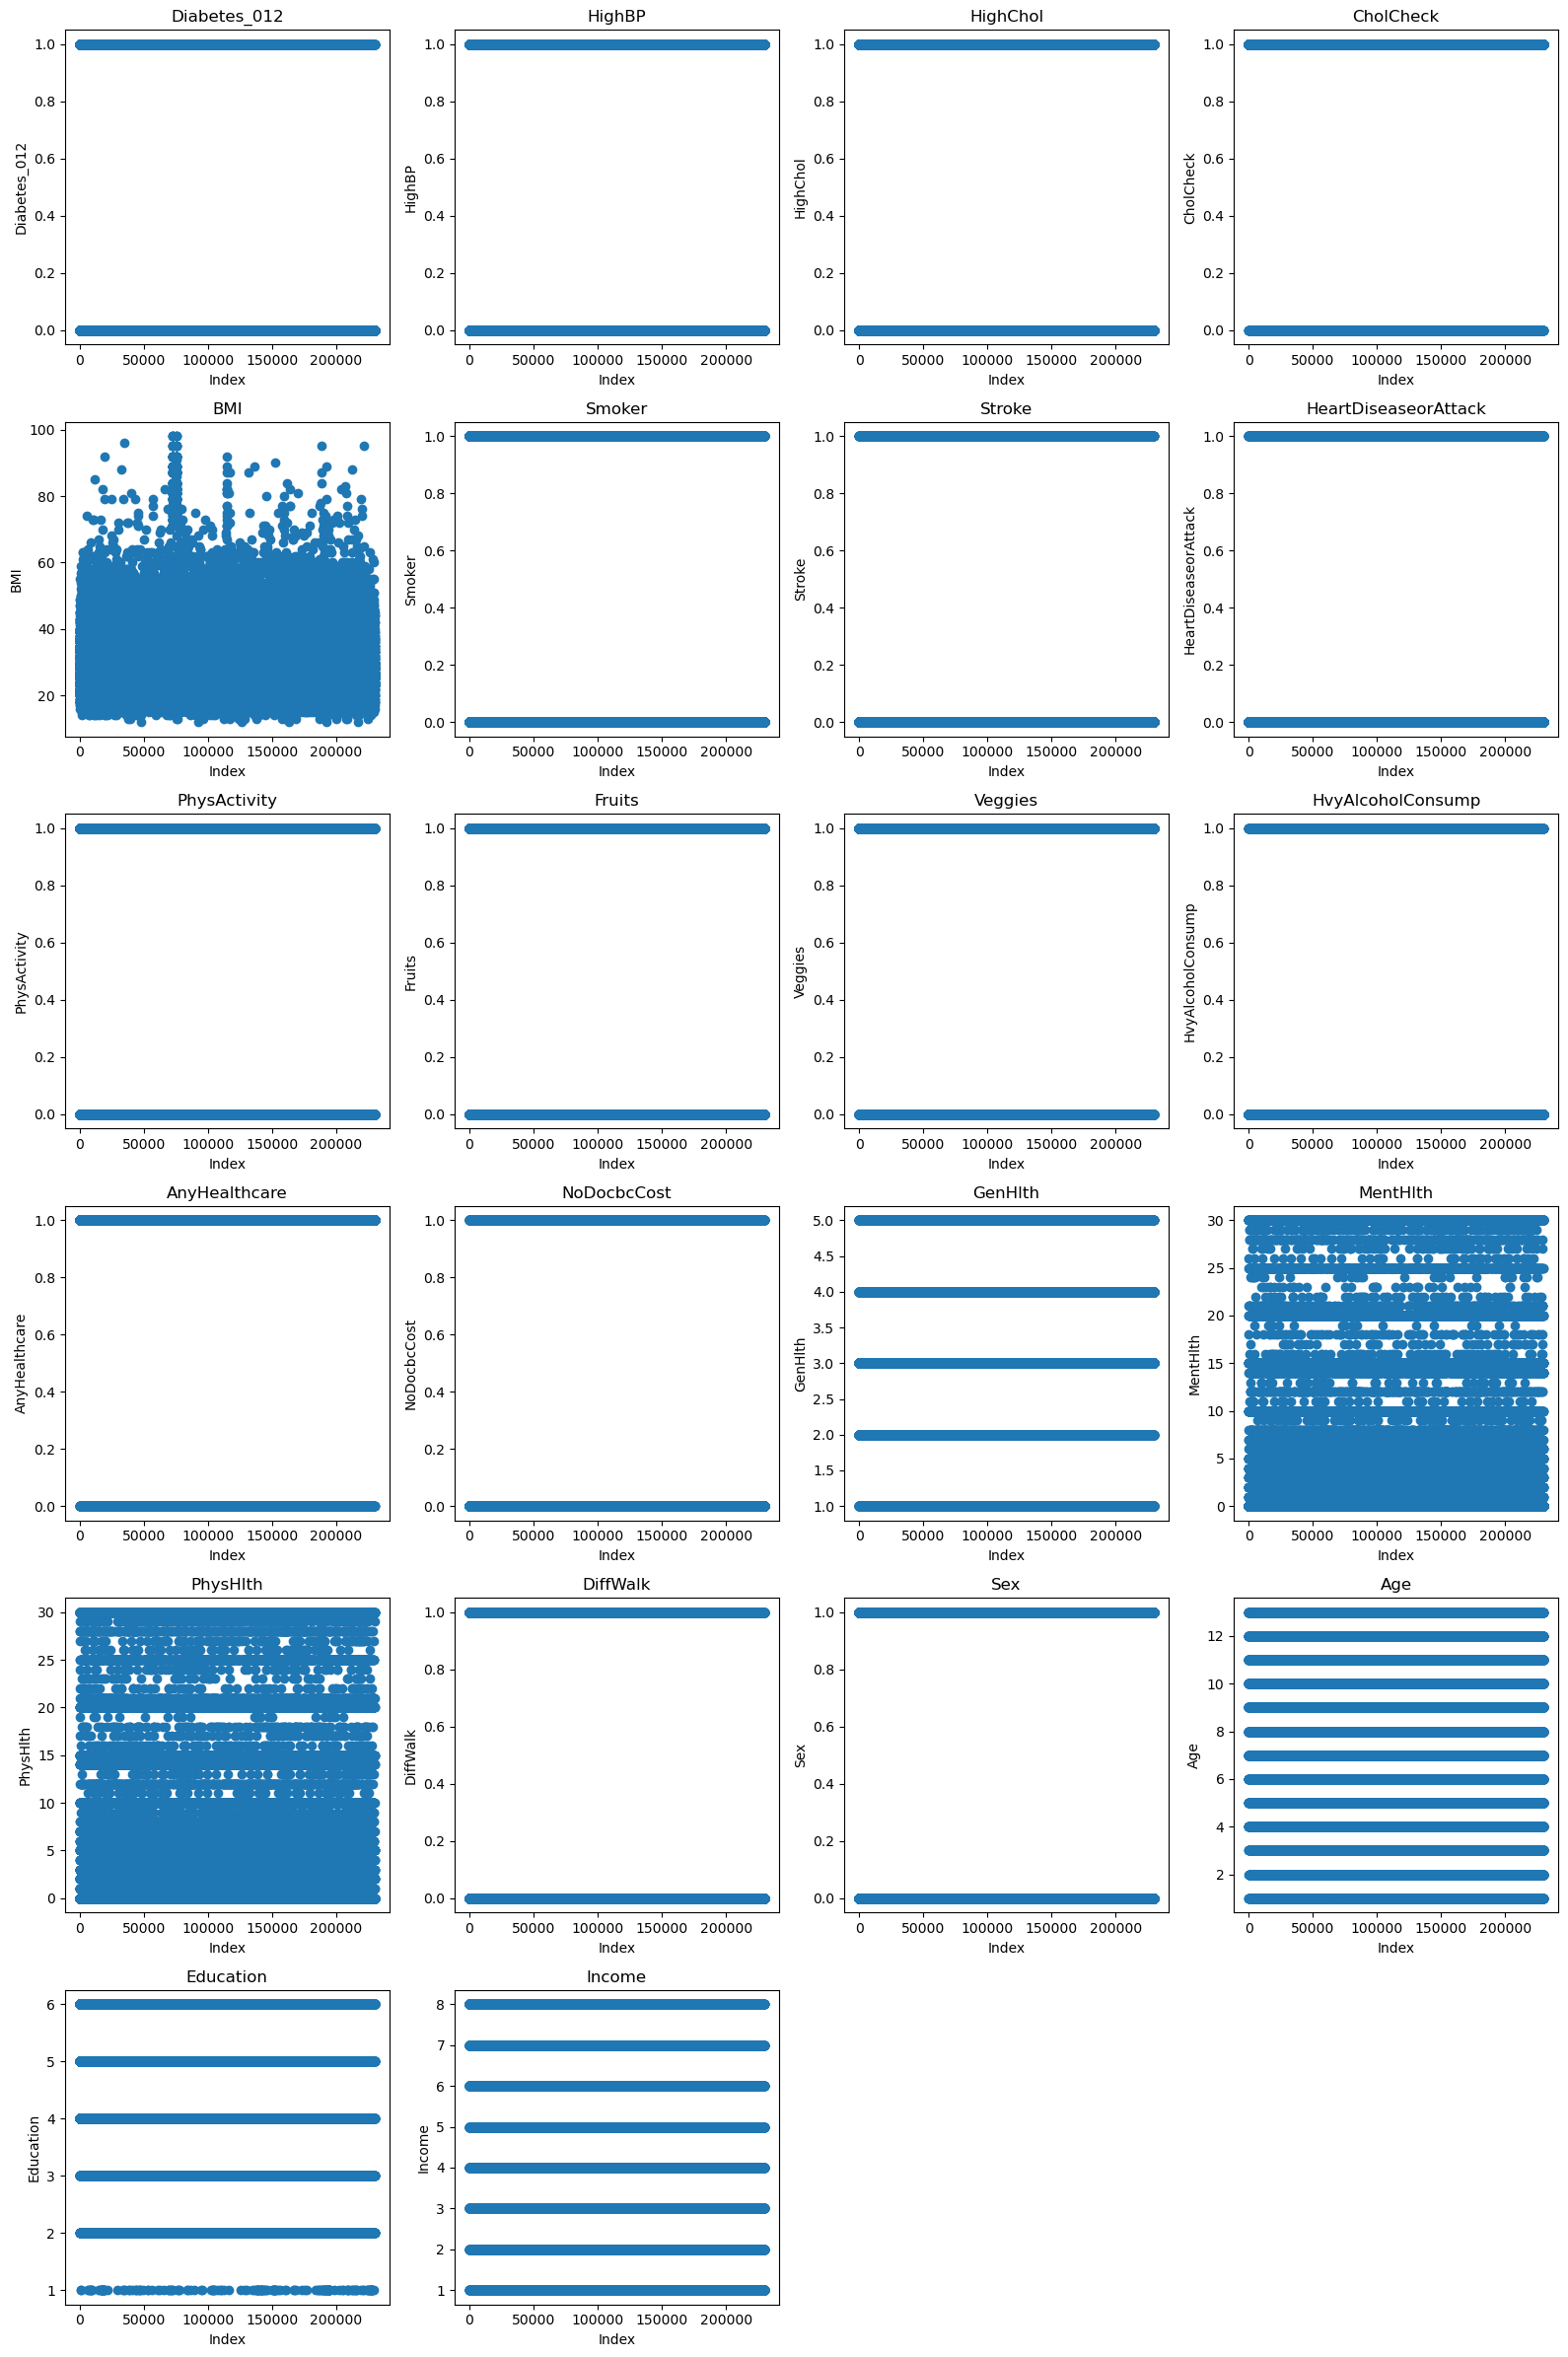

In [17]:
dot_plt_all_features (df_no_dup)

In [18]:
df_label = df_no_dup[["Diabetes_012"]]
df_binary = df_no_dup[["HighBP", 
                       "HighChol",
                       "CholCheck",  
                       "Smoker",  
                       "Stroke",  
                       "HeartDiseaseorAttack",  
                       "PhysActivity",  
                       "Fruits",  
                       "Veggies",  
                       "HvyAlcoholConsump",  
                       "AnyHealthcare",  
                       "NoDocbcCost",  
                       "DiffWalk",  
                       "Sex"
                       ]]

df_ordinal = df_no_dup[["GenHlth",
                        "Age",
                        "Education",
                        "Income"
                       ]]

df_continuous = df_no_dup[["BMI",
                           "MentHlth",
                           "PhysHlth"
                           ]]

In [19]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229712 entries, 0 to 229711
Data columns (total 1 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Diabetes_012  229712 non-null  float64
dtypes: float64(1)
memory usage: 1.8 MB


In [20]:
# could be skipped if is binary class
df_1_hot_label = pd.get_dummies(df_label["Diabetes_012"], prefix = "Diabetes_class").astype(int)
print(df_1_hot_label)

        Diabetes_class_0.0  Diabetes_class_1.0
0                        1                   0
1                        1                   0
2                        1                   0
3                        1                   0
4                        1                   0
...                    ...                 ...
229707                   1                   0
229708                   0                   1
229709                   1                   0
229710                   1                   0
229711                   0                   1

[229712 rows x 2 columns]


In [21]:
# Z-score normalize
# Works well with MLPs -> inputs are centered near 0
# Requires global mean/std -> in FL must be computed via federated statistics aggregation.

def z_scalling (df):
    z_scaler = StandardScaler()
    df_normalized = pd.DataFrame(
        z_scaler.fit_transform(df),
        columns = df.columns
    )
    return (df_normalized)

In [22]:
df_ordinal_norm = z_scalling(df_ordinal)
print(df_ordinal_norm)

         GenHlth       Age  Education    Income
0       2.252865  0.295419  -0.987379 -1.381086
1       0.374534 -0.351000   1.026882 -2.336862
2       2.252865  0.295419  -0.987379  1.008353
3      -0.564631  0.941838  -1.994510  0.052577
4      -0.564631  0.941838   0.019751 -0.903198
...          ...       ...        ...       ...
229707  0.374534 -0.997418   1.026882  0.530465
229708  1.313700  0.941838  -3.001641 -0.903198
229709 -1.503796 -1.967047   0.019751 -1.858974
229710  0.374534 -0.351000   0.019751 -2.336862
229711 -0.564631  0.295419   1.026882 -1.858974

[229712 rows x 4 columns]


In [23]:
df_continuous_norm = z_scalling(df_continuous)
print(df_continuous_norm)

             BMI  MentHlth  PhysHlth
0       1.667028  1.878714  1.141054
1      -0.543046 -0.454517 -0.516880
2      -0.101031  3.434200  2.798988
3      -0.248370 -0.454517 -0.516880
4      -0.690385 -0.065645 -0.516880
...          ...       ...       ...
229707  2.403719 -0.454517  0.035764
229708 -1.574414 -0.454517 -0.516880
229709 -0.101031 -0.454517 -0.516880
229710 -0.837723 -0.454517 -0.516880
229711 -0.543046 -0.454517 -0.516880

[229712 rows x 3 columns]


In [24]:
# Things remains: (mainly FL related)
# 1. Feature Alignment -> same feature order + dimensionality
# 2. Consistent encode mapping across sites -> eg. Smoker: {No=0, Yes=1}.
# 3. (OPTIONAL) resampling to get rid of class imbalancement

In [25]:
# Combine along columns (axis=1)
df_tabular_ready = pd.concat(
    [df_binary, df_ordinal_norm, df_continuous_norm, df_label], 
    axis=1)

In [26]:
df_tabular_ready.head()

,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,...,DiffWalk,Sex,GenHlth,Age,Education,Income,BMI,MentHlth,PhysHlth,Diabetes_012
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.252865,0.295419,-0.987379,-1.381086,1.667028,1.878714,1.141054,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.374534,-0.351000,1.026882,-2.336862,-0.543046,-0.454517,-0.516880,0.0
2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,2.252865,0.295419,-0.987379,1.008353,-0.101031,3.434200,2.798988,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,-0.564631,0.941838,-1.994510,0.052577,-0.248370,-0.454517,-0.516880,0.0
4,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,-0.564631,0.941838,0.019751,-0.903198,-0.690385,-0.065645,-0.516880,0.0


In [28]:
df_tabular_ready.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229712 entries, 0 to 229711
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                229712 non-null  float64
 1   HighChol              229712 non-null  float64
 2   CholCheck             229712 non-null  float64
 3   Smoker                229712 non-null  float64
 4   Stroke                229712 non-null  float64
 5   HeartDiseaseorAttack  229712 non-null  float64
 6   PhysActivity          229712 non-null  float64
 7   Fruits                229712 non-null  float64
 8   Veggies               229712 non-null  float64
 9   HvyAlcoholConsump     229712 non-null  float64
 10  AnyHealthcare         229712 non-null  float64
 11  NoDocbcCost           229712 non-null  float64
 12  DiffWalk              229712 non-null  float64
 13  Sex                   229712 non-null  float64
 14  GenHlth               229712 non-null  float64
 15  

In [29]:
df_tabular_ready.to_csv("tabular_dataset/diabetes_012_ready_to_model.csv", index=False)

In [30]:
# train-val-test split

# train + val vs test
tabular_train_val, tabular_test = train_test_split(
    df_tabular_ready, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = df_tabular_ready["Diabetes_012"]
    )

# train vs val
tabular_train, tabular_val = train_test_split(
    tabular_train_val, 
    test_size = 0.25, 
    random_state = 42, 
    stratify = tabular_train_val["Diabetes_012"]
    )

In [ ]:
# record other useful info for model
d_tabular = 21
n_tabular_classes = df_1_hot_label.shape[1]

# write to tabular_info.py
with open("tabular_info.py", "w") as f:
    f.write("d_tabular = {:d}\n".format(d_tabular))
    f.write("n_tabular_classes = {:d}\n".format(n_tabular_classes))
